In [ ]:
import pandas as pd

df = pd.read_csv("/content/Train.csv")

print(df.head())

       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
df['Work_Experience'] = df['Work_Experience'].fillna(
    df['Work_Experience'].median()
)

In [ ]:
df['Family_Size'] = df['Family_Size'].fillna(
    df['Family_Size'].median()
)

df['Var_1'] = df['Var_1'].fillna(
    df['Var_1'].mode()[0]
)

In [ ]:
df['Ever_Married'] = df['Ever_Married'].fillna(
    df['Ever_Married'].mode()[0]
)

df['Graduated'] = df['Graduated'].fillna(
    df['Graduated'].mode()[0]
)

df['Profession'] = df['Profession'].fillna(
    df['Profession'].mode()[0]
)

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [ ]:
df = df.drop(['ID', 'Segmentation'], axis=1, errors='ignore')
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape

(8068, 22)

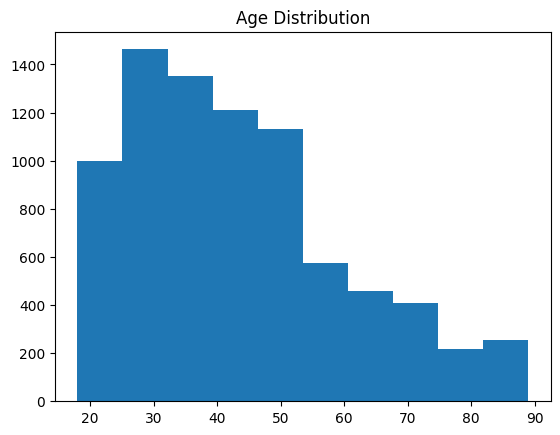

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()

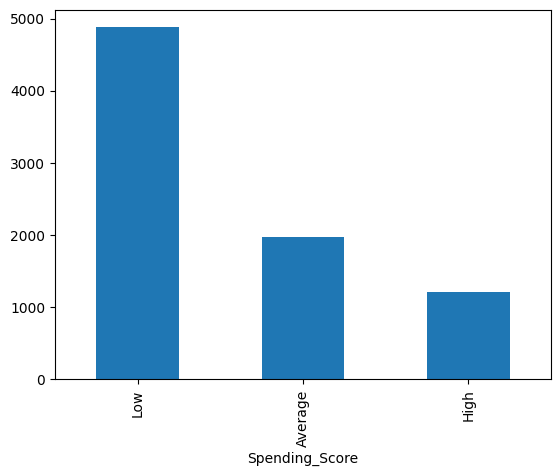

In [ ]:
df['Spending_Score'].value_counts()
df['Spending_Score'].value_counts().plot(kind='bar')
plt.show()

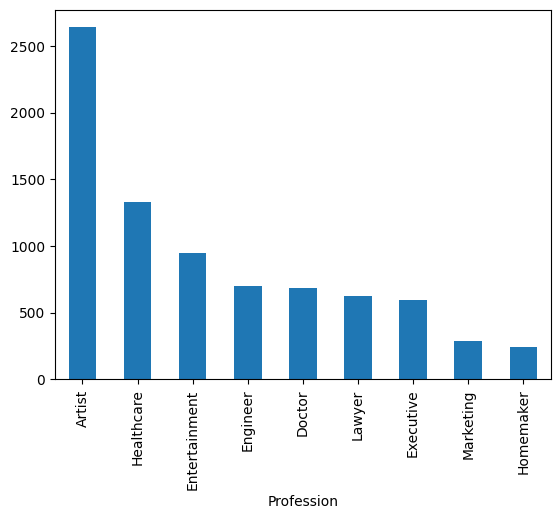

In [ ]:
df['Profession'].value_counts().plot(kind='bar')
plt.show()

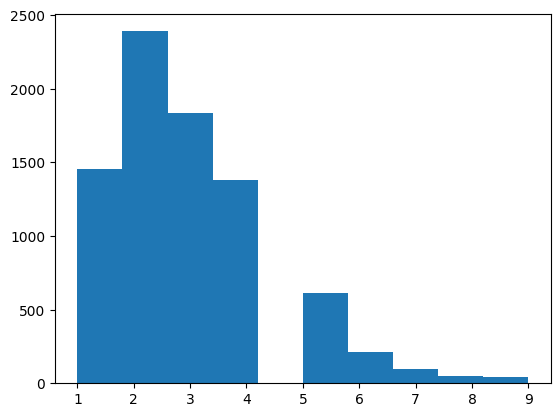

In [ ]:
plt.hist(df['Family_Size'])
plt.show()

In [ ]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.shape

(8068, 22)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

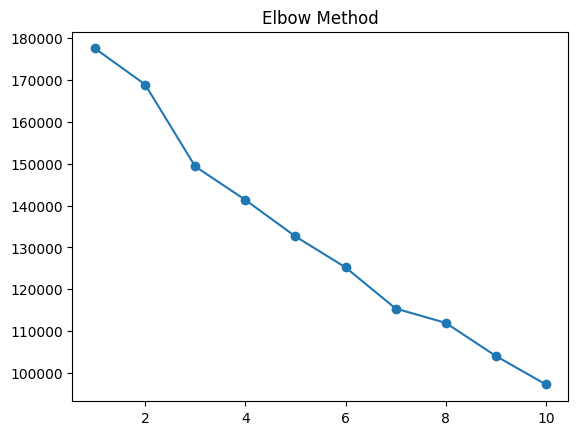

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [ ]:

df.groupby('Cluster').size()

,0
Cluster,
0,677
1,1885
2,719
3,1113
4,737
5,582
6,1369
7,614
8,85


In [ ]:
df.groupby('Cluster').mean(
    numeric_only=True
)

,Age,Work_Experience,Family_Size
Cluster,,,
0,44.254062,2.844904,2.666174
1,49.477984,2.168170,2.726790
2,38.239221,2.390821,2.916551
3,26.190476,2.343217,3.712489
4,40.345997,2.280868,3.314790
5,51.634021,2.149485,3.429553
6,37.108839,3.676406,2.222790
7,75.677524,1.174267,1.972313
8,37.164706,2.811765,3.552941


In [ ]:
pd.crosstab(
    df['Cluster'],
    df['Spending_Score']
)

Spending_Score,Average,High,Low
Cluster,,,
0,220,34,423
1,1139,316,430
2,189,42,488
3,13,8,1092
4,275,55,407
5,75,397,110
6,10,0,1359
7,16,324,274
8,20,7,58


In [ ]:
pd.crosstab(
    df['Cluster'],
    df['Profession']
)

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster,,,,,,,,,
0,0,0,0,677,0,0,0,0,0
1,1479,150,162,0,0,42,52,0,0
2,223,78,88,125,8,146,48,3,0
3,14,0,0,0,0,1098,0,1,0
4,231,105,205,137,6,24,28,1,0
5,0,0,0,0,582,0,0,0,0
6,669,351,235,0,1,0,112,1,0
7,0,0,0,0,0,0,0,614,0
8,24,4,9,10,2,22,6,3,5


In [ ]:
df.to_csv(
    "customer_segments.csv",
    index=False
)
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Cluster
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,3
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,1
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,7
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,0


In [ ]:
from google.colab import files
files.download('customer_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>